Noto Sans CJK JP
[QC] 관측월수 < 24개월인 ATC2 6개 발견: ['A01', 'A09', 'D02', 'P02', 'P03', 'V10']
     -> 시장 총계/atc2_monthly에는 유지되나, trend/momentum 통계와 is_flagged 판정에서는 제외되고 insufficient_data_flag=True 로 표시됩니다.
ATC2 총 78개 중 Flagged: 56개
  ATC2cd                                         ATC2cdNm  n_months_observed  \
0    A01                      STOMATOLOGICAL PREPARATIONS                 16   
1    A02                 DRUGS FOR ACID RELATED DISORDERS                 36   
2    A03  DRUGS FOR FUNCTIONAL GASTROINTESTINAL DISORDERS                 36   
3    A04                    ANTIEMETICS AND ANTINAUSEANTS                 36   
4    A05                           BILE AND LIVER THERAPY                 36   

   insufficient_data_flag  growth_data_incomplete_flag   market_2020  \
0                    True                         True  1.067247e+09   
1                   False                        False  7.817770e+11   
2                   False                        False  1.760797e+11   
3 

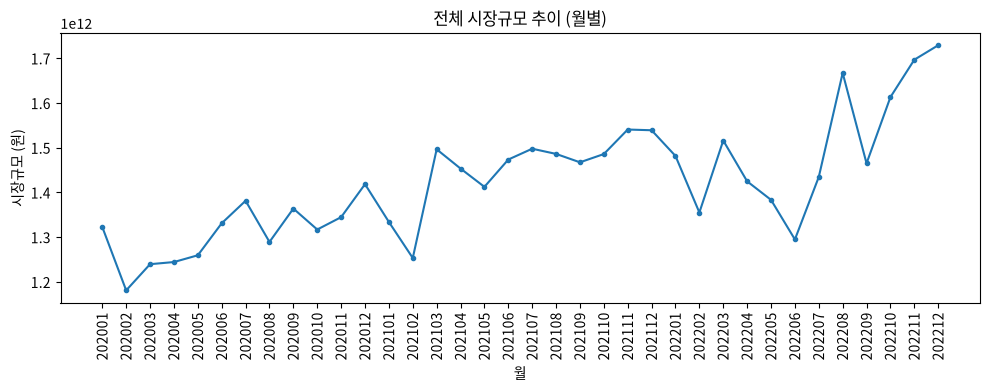

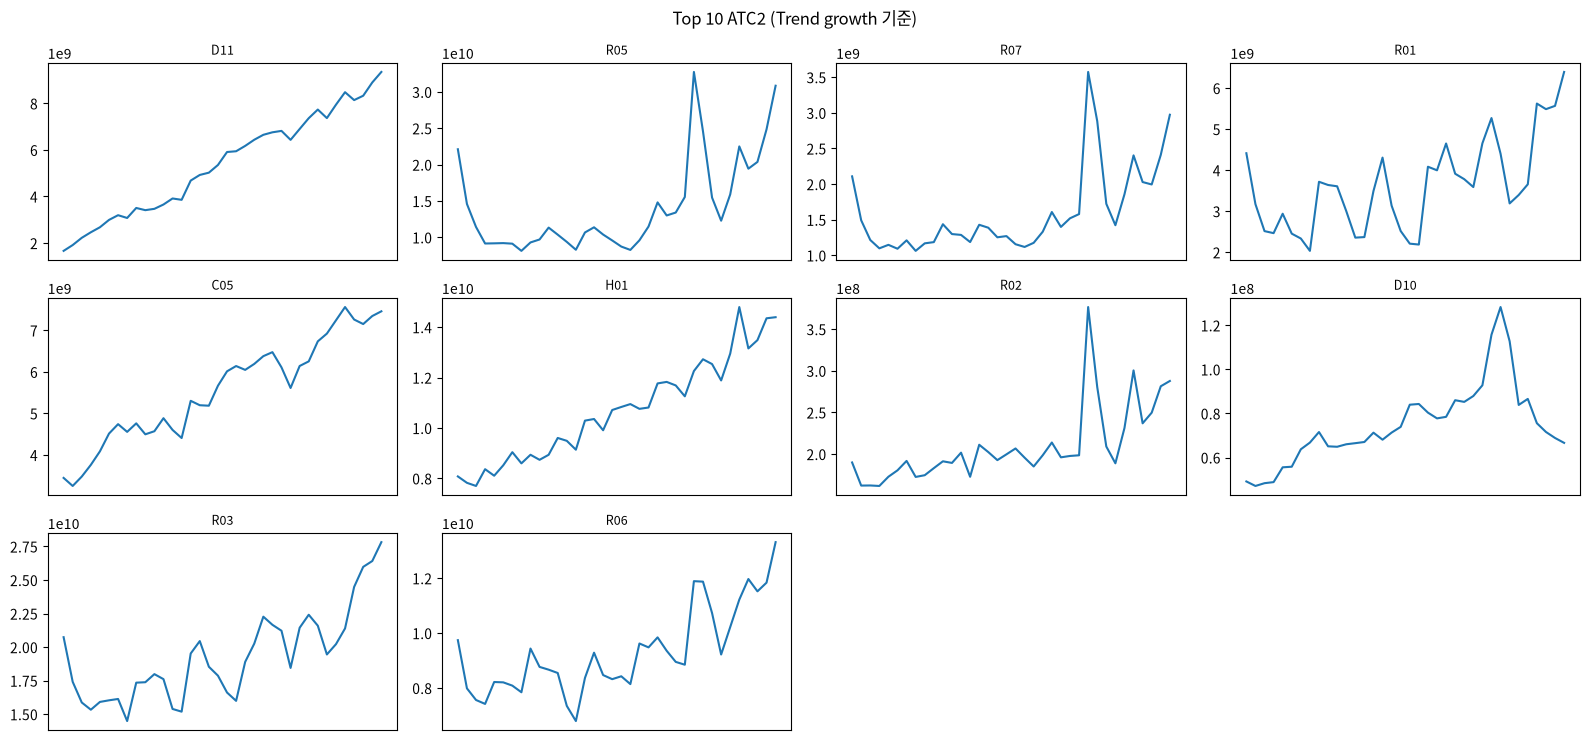

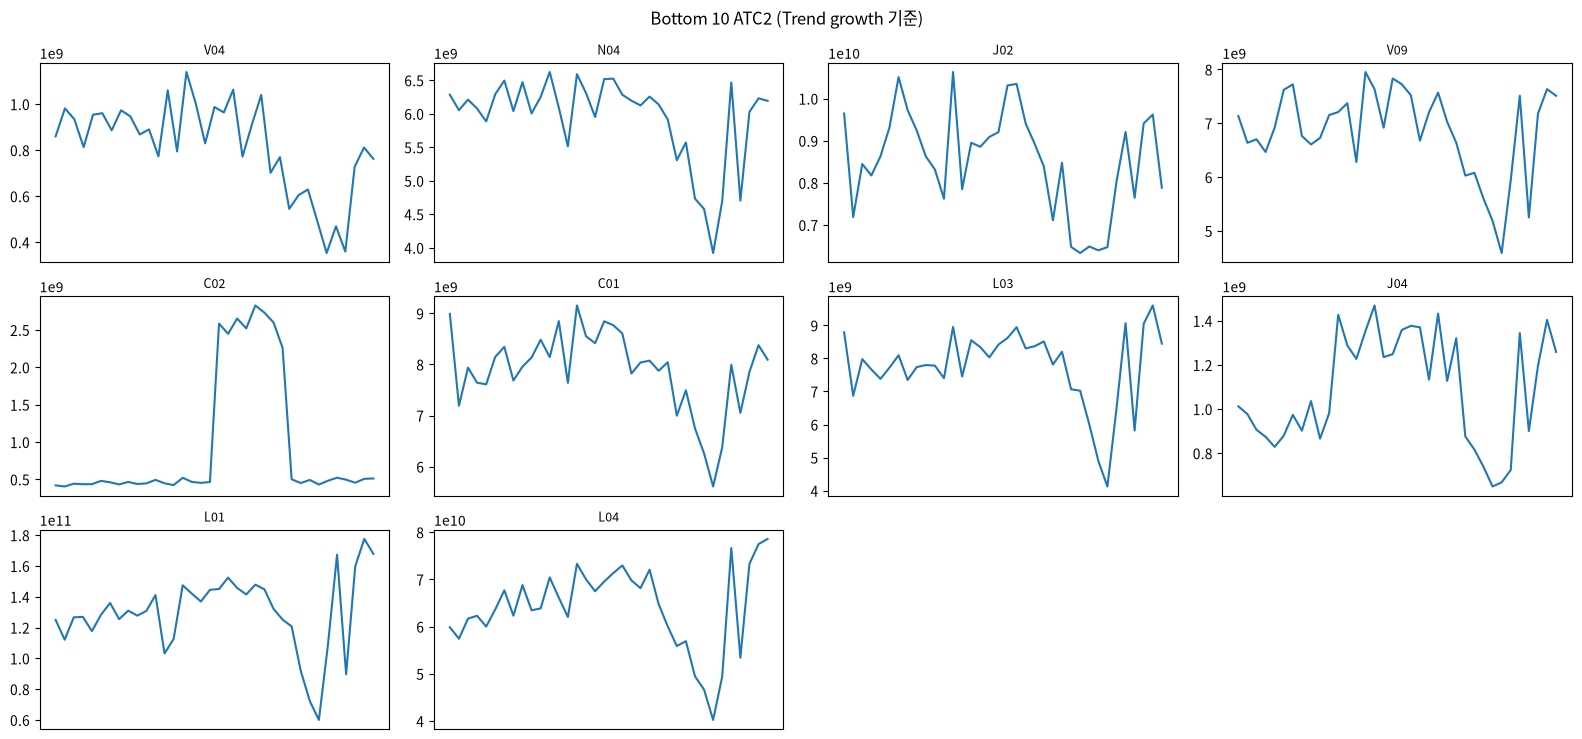

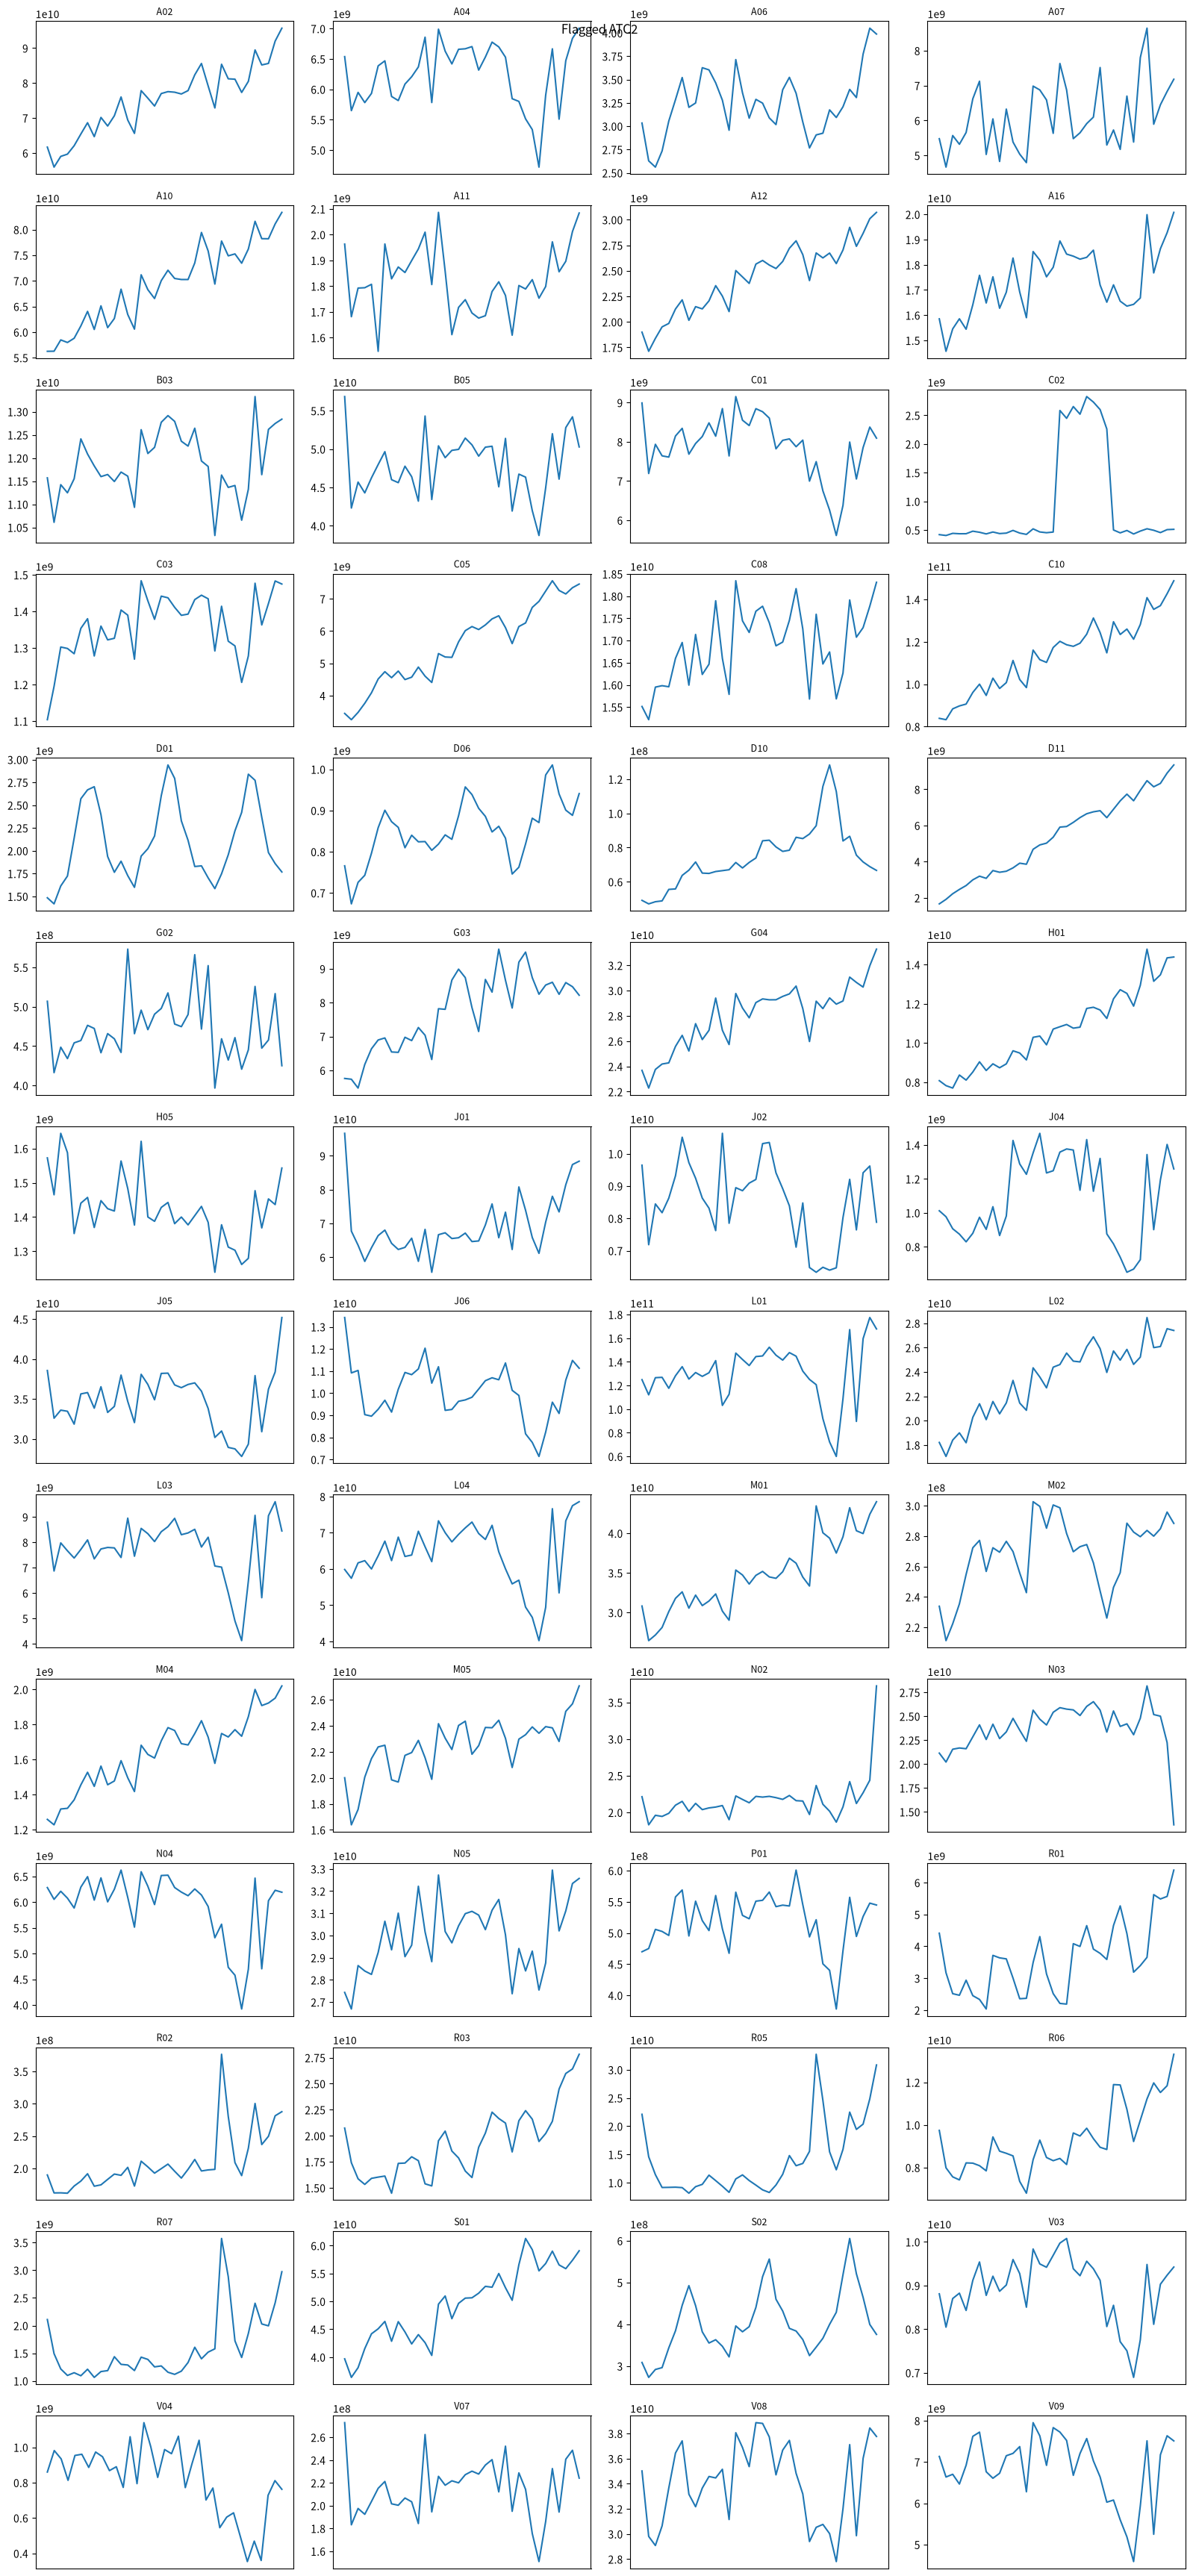

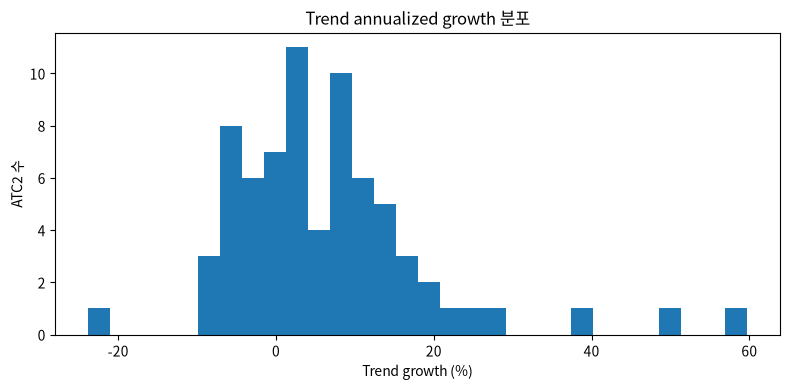

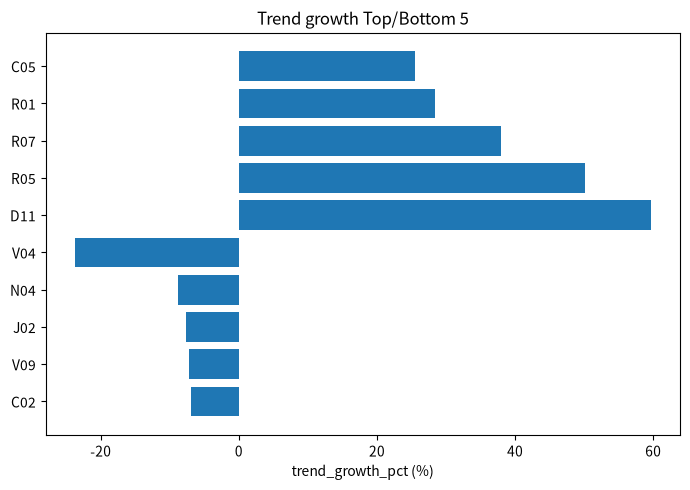

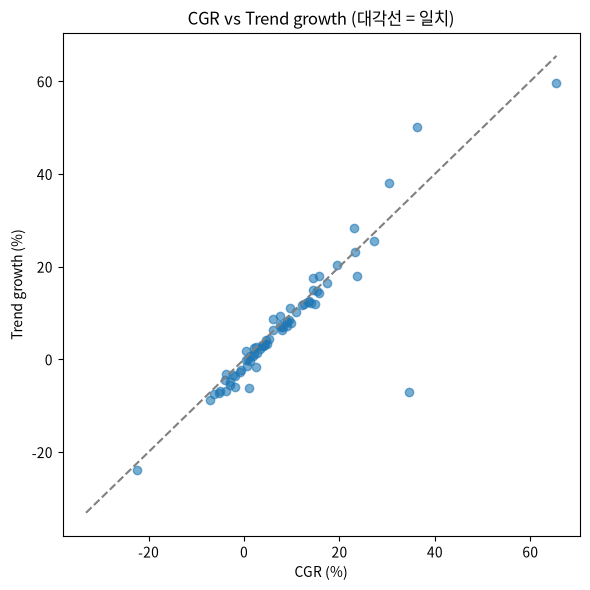

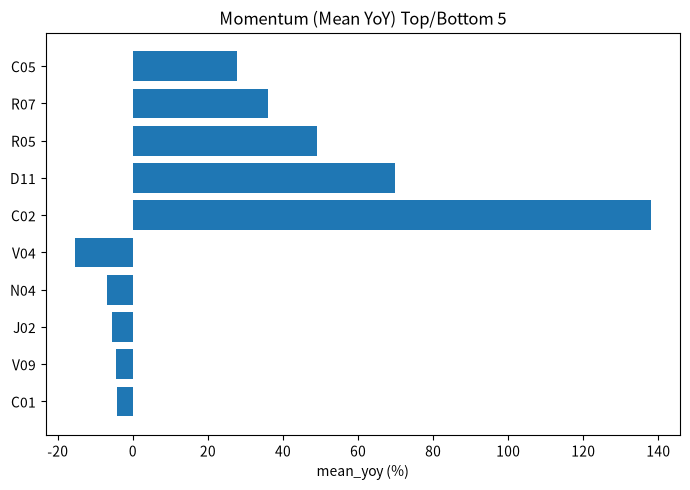

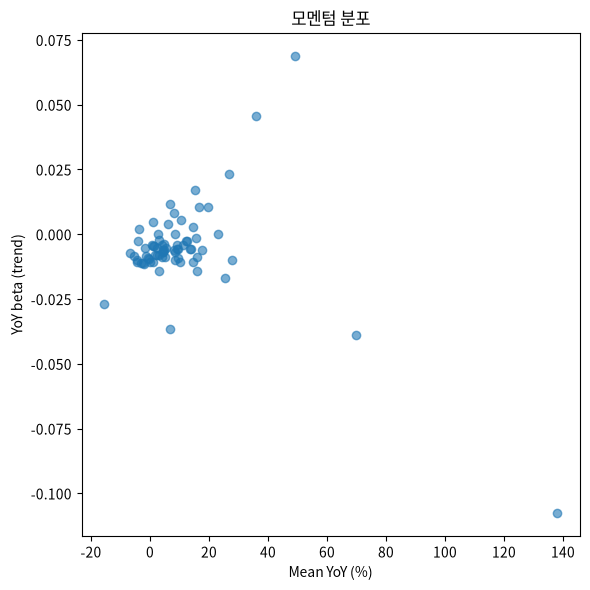

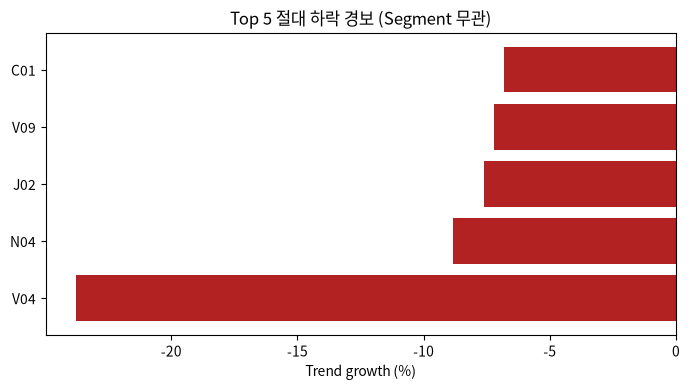

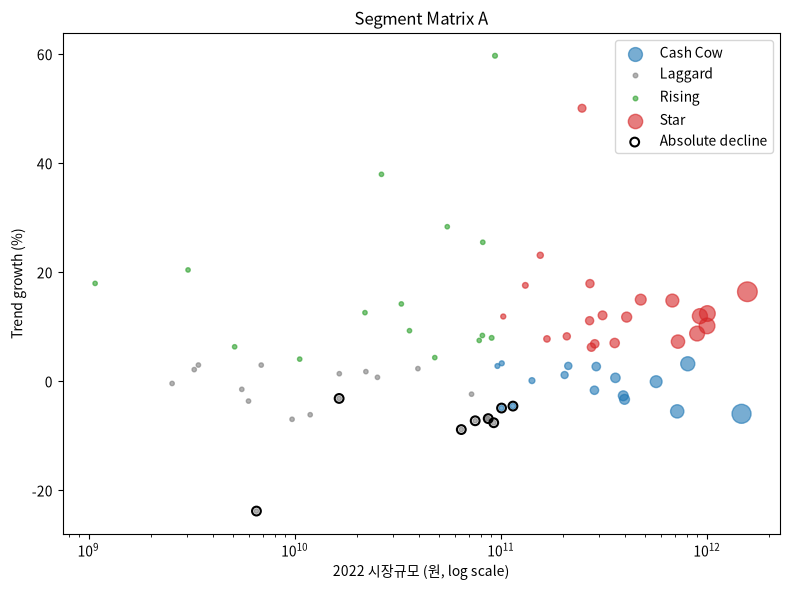

In [1]:
# -*- coding: utf-8 -*-
"""
Module 1 — ATC2 시장 탐색 (Market Scan)
=========================================

설계 문서(ATC3_SICK → ATC2 → Flagged ATC2 → ATC3 → 질병 → 지역×기관) 기준
Module 0(공통 정합성) + Module 1(M1-1 ~ M1-8) 구현.

전제 (create-db-pq_v2.ipynb 확인 결과):
    - atc3_sick VIEW 컬럼:
        atcStep3Cd, atcStep3CdNm, diagYm('YYYYMM' VARCHAR),
        insupTpCd, st3SickSym, st3SickSymNm,
        totUseQty (BIGINT, 사용량), msupUseAmt (BIGINT, 사용금액)
      -> 이미 원본 parquet의 컬럼 스왑 문제가 VIEW 생성 시 보정되어 있음.
    - atc_master VIEW 컬럼:
        atc_code (1~4자리 ATC 계층 코드 전부 포함), atc_name, strength, uom, adm_r, note
      -> ATC2 명칭은 atc_code = LEFT(atcStep3Cd, 3) 로 조인해서 획득.
    - diagYm 범위: 202001 ~ 202212 (36개월, 결측 없음). 3개 연도(2020/2021/2022).

이 스크립트는 기존 create-db-pq_v2.ipynb 와 동일한 healthcare.duckdb 에 연결해서
이어서 실행하는 것을 전제로 합니다 (해당 노트북의 셀들을 먼저 실행해 VIEW들이
만들어져 있어야 합니다). 노트북 셀로 나눠 붙여넣거나, 그대로 스크립트로 실행해도 됩니다.
"""

from __future__ import annotations

import duckdb
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print(font_name)


# ============================================================
# CONFIG — 프로젝트 정책에 따라 조정 가능한 임계값들
# ============================================================

CONFIG = {
    # 데이터 커버리지 (전체 36개월 중 최소 필요 관측월 수)
    "total_months": 36,
    # trend(WLS: 절편+Time+월더미11개=13개 파라미터)와 momentum(YoY, t-12 shift +
    # early/late 분할회귀)이 안정적으로 추정되려면 최소 2/3(=24개월) 이상의 관측치가
    # 필요하다고 보고 이 값을 기준으로 삼음. 미만이면 통계치는 계산하지 않고
    # insufficient_data_flag=True 로 남겨 투명하게 노출한다 (완전 제외 아님).
    "min_months_required": 24,

    # M1-2 : trend WLS
    "recency_halflife_months": 12,   # 최근월에 가중치를 실어주는 half-life (개월)
    "outlier_z_threshold": 2.0,      # 표준화 잔차 이상치 판정 기준
    "robust_flag_outlier_ratio": 0.10,  # 이상치 비율이 이 값을 넘으면 robust_flag=True

    # M1-6 : absolute decline
    "decline_tstat_threshold": 2.0,  # |t_stat| >= 이 값이면 유의한 하락으로 판정

    # M1-8 : flag 기준 (분위수 기반, 데이터 분포에 따라 자동 조정됨)
    "growth_flag_quantile": 0.75,        # trend_growth_pct 상위 25%
    "momentum_flag_pvalue": 0.10,        # beta_diff 유의수준
    "reliability_flag_pvalue": 0.05,     # trend 자체가 불안정한 경우
    "reliability_flag_gap_quantile": 0.75,  # |trend_cgr_gap| 상위 25%
    "volatility_flag_quantile": 0.75,    # yoy_sd 또는 resid_sd 상위 25%
    "flag_min_count_for_flagged": 1,     # is_flagged 판정을 위한 최소 flag 개수

    "db_path": "healthcare.duckdb",
}


# ============================================================
# Module 0 — 공통 정합성 / 기준 데이터 (atc3_sick_base)
# ============================================================

def create_atc3_sick_base(con: duckdb.DuckDBPyConnection) -> None:
    """
    ATC2cd = LEFT(ATC3cd, 3) 파생 + atc_master 조인으로 ATC2cdNm 획득.
    materialize하지 않고 VIEW로 유지 (설계 원칙).
    """
    con.execute("""
        CREATE OR REPLACE VIEW atc3_sick_base AS
        SELECT
            s.diagYm,
            LEFT(s.diagYm, 4)::INTEGER   AS diag_year,
            RIGHT(s.diagYm, 2)::INTEGER  AS diag_month,
            LEFT(s.atcStep3Cd, 3)        AS ATC2cd,
            COALESCE(m2.atc_name, 'UNKNOWN') AS ATC2cdNm,
            s.atcStep3Cd                 AS ATC3cd,
            s.atcStep3CdNm                AS ATC3cdNm,
            s.st3SickSym,
            s.st3SickSymNm,
            s.insupTpCd,
            s.msupUseAmt,
            s.totUseQty
        FROM atc3_sick s
        LEFT JOIN atc_master m2
            ON m2.atc_code = LEFT(s.atcStep3Cd, 3)
    """)


# ============================================================
# M1-1 — 월별 시장규모 (atc2_monthly)
# ============================================================

def build_atc2_monthly(con: duckdb.DuckDBPyConnection) -> pd.DataFrame:
    con.execute("""
        CREATE OR REPLACE VIEW atc2_monthly AS
        SELECT
            ATC2cd,
            ANY_VALUE(ATC2cdNm)                                     AS ATC2cdNm,
            diag_year                                               AS year,
            diag_month                                              AS month,
            diagYm                                                  AS ym,
            SUM(msupUseAmt)                                         AS market_amount,
            CASE WHEN SUM(msupUseAmt) > 0
                 THEN LN(SUM(msupUseAmt))
                 ELSE NULL END                                      AS log_market
        FROM atc3_sick_base
        GROUP BY ATC2cd, diag_year, diag_month, diagYm
    """)
    df = con.execute("SELECT * FROM atc2_monthly ORDER BY ATC2cd, ym").fetchdf()
    # 시간 인덱스 (그룹 내 1..36) — 회귀분석에서 사용
    df["time_idx"] = df.groupby("ATC2cd").cumcount() + 1
    return df


def build_atc2_coverage(monthly_df: pd.DataFrame, cfg: dict = CONFIG) -> pd.DataFrame:
    """
    ATC2별 데이터 커버리지 진단.

    atc2_monthly 는 SUM(msupUseAmt) 결과이므로, 특정 월에 해당 ATC2의 처방 레코드가
    아예 없으면(=진짜 0건 청구) 그 달은 GROUP BY 결과에 아예 나타나지 않는다.
    즉 "36개월 중 일부만 존재"하는 것은 데이터 파이프라인 오류가 아니라 니치 시장의
    특성일 수 있으므로, 시장 총계에서는 빼지 않되 통계 모델링(trend/momentum) 대상
    여부만 이 커버리지로 판단한다.
    """
    cov = (
        monthly_df.groupby("ATC2cd")
        .agg(n_months_observed=("ym", "nunique"))
        .reset_index()
    )
    cov["coverage_ratio"] = cov["n_months_observed"] / cfg["total_months"]
    cov["insufficient_data_flag"] = cov["n_months_observed"] < cfg["min_months_required"]

    # 2020 / 2022 개별 연도 커버리지 (M1-3 CGR 신뢰성 판단용)
    for year in (2020, 2022):
        n_col = f"n_months_{year}"
        sub = (
            monthly_df[monthly_df["year"] == year]
            .groupby("ATC2cd")["ym"].nunique()
            .rename(n_col)
        )
        cov = cov.merge(sub, on="ATC2cd", how="left")
        cov[n_col] = cov[n_col].fillna(0).astype(int)

    cov["growth_data_incomplete_flag"] = (cov["n_months_2020"] < 12) | (cov["n_months_2022"] < 12)
    return cov


# ============================================================
# M1-2 — 구조적 Trend (WLS: log(Y_t) = a + b*Time + MonthDummy + e)
# ============================================================

def _weighted_ols(X: np.ndarray, y: np.ndarray, w: np.ndarray):
    """
    WLS를 numpy로 직접 계산. beta, se, t_stat, p_value, r2, resid, resid_sd 반환.
    """
    n, k = X.shape
    W = np.diag(w)
    XtW = X.T @ W
    XtWX = XtW @ X
    XtWy = XtW @ y

    XtWX_inv = np.linalg.pinv(XtWX)
    beta = XtWX_inv @ XtWy

    y_hat = X @ beta
    resid = y - y_hat

    sse_w = float(w @ (resid ** 2))
    y_bar_w = float(np.sum(w * y) / np.sum(w))
    sst_w = float(w @ ((y - y_bar_w) ** 2))
    r2 = 1 - sse_w / sst_w if sst_w > 0 else np.nan

    dof = max(n - k, 1)
    sigma2 = sse_w / dof
    cov = sigma2 * XtWX_inv
    se = np.sqrt(np.clip(np.diag(cov), 0, None))

    with np.errstate(divide="ignore", invalid="ignore"):
        t_stat = beta / se
    p_value = 2 * stats.t.sf(np.abs(t_stat), df=dof)

    resid_sd = float(np.std(resid, ddof=min(1, n - 1)))
    return {
        "beta": beta, "se": se, "t_stat": t_stat, "p_value": p_value,
        "r2": r2, "resid": resid, "resid_sd": resid_sd, "dof": dof,
    }


def _make_design_matrix(g: pd.DataFrame):
    """intercept + time_idx + month dummies(2..12, 11개) 설계행렬."""
    n = len(g)
    intercept = np.ones(n)
    time_idx = g["time_idx"].to_numpy(dtype=float)

    month_dummies = pd.get_dummies(g["month"], prefix="m", drop_first=True)
    # 항상 동일한 컬럼 순서 보장 (일부 ATC2가 특정 월 데이터 없을 가능성 대비)
    for m in range(2, 13):
        col = f"m_{m}"
        if col not in month_dummies.columns:
            month_dummies[col] = 0
    month_dummies = month_dummies[[f"m_{m}" for m in range(2, 13)]]

    X = np.column_stack([intercept, time_idx, month_dummies.to_numpy(dtype=float)])
    return X


def _recency_weights(g: pd.DataFrame, halflife: float) -> np.ndarray:
    T = g["time_idx"].max()
    t = g["time_idx"].to_numpy(dtype=float)
    # 최근월(t=T)일수록 weight=1, 과거로 갈수록 0.5^(distance/halflife)로 감소
    w = 0.5 ** ((T - t) / halflife)
    return w


def fit_atc2_trend(monthly_df: pd.DataFrame, cfg: dict = CONFIG) -> pd.DataFrame:
    """
    ATC2별 WLS trend 추정. 커버리지가 cfg["min_months_required"] 미만인 그룹은
    회귀를 시도하지 않고 NaN 지표 + insufficient_data_flag=True 행으로 남긴다
    (완전히 drop하면 이후 merge에서 조용히 사라져 원인 파악이 어려워짐).
    """
    rows = []
    for atc2cd, g_raw in monthly_df.groupby("ATC2cd"):
        g = g_raw.sort_values("time_idx").dropna(subset=["log_market"])

        if len(g) < cfg["min_months_required"]:
            rows.append({
                "ATC2cd": atc2cd,
                "trend_beta": np.nan, "trend_growth_pct": np.nan, "r2": np.nan,
                "t_stat": np.nan, "p_value": np.nan, "resid_sd": np.nan,
                "outlier_count": np.nan, "robust_flag": False,
                "trend_insufficient_data": True,
            })
            continue

        X = _make_design_matrix(g)
        y = g["log_market"].to_numpy(dtype=float)
        w = _recency_weights(g, cfg["recency_halflife_months"])

        fit = _weighted_ols(X, y, w)
        beta_time = fit["beta"][1]
        se_time = fit["se"][1]
        t_time = fit["t_stat"][1]
        p_time = fit["p_value"][1]

        resid_std = fit["resid_sd"] if fit["resid_sd"] > 0 else np.nan
        std_resid = fit["resid"] / resid_std if resid_std and not np.isnan(resid_std) else fit["resid"] * np.nan
        outlier_count = int(np.sum(np.abs(std_resid) > cfg["outlier_z_threshold"]))
        outlier_ratio = outlier_count / len(g)
        robust_flag = outlier_ratio > cfg["robust_flag_outlier_ratio"]

        rows.append({
            "ATC2cd": atc2cd,
            "trend_beta": beta_time,
            "trend_growth_pct": np.exp(beta_time * 12) - 1,
            "r2": fit["r2"],
            "t_stat": t_time,
            "p_value": p_time,
            "resid_sd": fit["resid_sd"],
            "outlier_count": outlier_count,
            "robust_flag": robust_flag,
            "trend_insufficient_data": False,
        })
    return pd.DataFrame(rows)


# ============================================================
# M1-3 — 2020 → 2022 성장 (atc2_growth)
# ============================================================

def build_atc2_growth(con: duckdb.DuckDBPyConnection) -> pd.DataFrame:
    df = con.execute("""
        WITH annual AS (
            SELECT ATC2cd, diag_year AS year, SUM(msupUseAmt) AS market_amount
            FROM atc3_sick_base
            WHERE diag_year IN (2020, 2022)
            GROUP BY ATC2cd, diag_year
        )
        SELECT
            ATC2cd,
            MAX(CASE WHEN year = 2020 THEN market_amount END) AS market_2020,
            MAX(CASE WHEN year = 2022 THEN market_amount END) AS market_2022
        FROM annual
        GROUP BY ATC2cd
    """).fetchdf()

    df["growth_amount"] = df["market_2022"] - df["market_2020"]
    df["cgr"] = np.where(
        (df["market_2020"] > 0) & (df["market_2022"] > 0),
        (df["market_2022"] / df["market_2020"]) ** (1 / 2) - 1,
        np.nan,
    )
    return df


# ============================================================
# M1-4 — 신뢰도 진단 (trend_cgr_gap) : merge 단계에서 계산
# ============================================================

def add_trend_cgr_gap(df: pd.DataFrame) -> pd.DataFrame:
    df["trend_cgr_gap"] = df["cgr"] - df["trend_growth_pct"]
    return df


# ============================================================
# M1-5 — Rolling YoY / Momentum
# ============================================================

def build_atc2_yoy_monthly(monthly_df: pd.DataFrame) -> pd.DataFrame:
    df = monthly_df.sort_values(["ATC2cd", "time_idx"]).copy()
    df["market_amount_lag12"] = df.groupby("ATC2cd")["market_amount"].shift(12)
    df["yoy_growth"] = df["market_amount"] / df["market_amount_lag12"] - 1
    return df[["ATC2cd", "ym", "time_idx", "market_amount", "yoy_growth"]]


def _ols_slope(t: np.ndarray, y: np.ndarray):
    """단순 OLS 기울기 + p-value (t vs y). 반환: beta, p_value."""
    mask = ~np.isnan(y)
    t, y = t[mask], y[mask]
    n = len(t)
    if n < 3:
        return np.nan, np.nan
    X = np.column_stack([np.ones(n), t])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    dof = n - 2
    sigma2 = float(resid @ resid) / dof if dof > 0 else np.nan
    XtX_inv = np.linalg.pinv(X.T @ X)
    se_slope = np.sqrt(sigma2 * XtX_inv[1, 1]) if dof > 0 else np.nan
    t_stat = beta[1] / se_slope if se_slope and not np.isnan(se_slope) and se_slope > 0 else np.nan
    p_value = 2 * stats.t.sf(np.abs(t_stat), df=dof) if not np.isnan(t_stat) else np.nan
    return beta[1], p_value


def build_atc2_momentum(yoy_df: pd.DataFrame, cfg: dict = CONFIG) -> pd.DataFrame:
    """
    YoY/모멘텀 추정. t-12 shift와 early/late 분할회귀가 필요하므로, 원본 월별
    관측치가 cfg["min_months_required"] 미만인 ATC2는 trend와 동일한 기준으로
    통계 산출을 건너뛰고 NaN + momentum_insufficient_data=True 행만 남긴다.
    """
    rows = []
    for atc2cd, g_raw in yoy_df.groupby("ATC2cd"):
        if g_raw["time_idx"].nunique() < cfg["min_months_required"]:
            rows.append({
                "ATC2cd": atc2cd,
                "mean_yoy": np.nan, "yoy_sd": np.nan, "yoy_beta": np.nan,
                "early_beta": np.nan, "late_beta": np.nan,
                "beta_diff": np.nan, "beta_diff_pvalue": np.nan,
                "momentum_insufficient_data": True,
            })
            continue

        g = g_raw.dropna(subset=["yoy_growth"]).sort_values("time_idx")
        if len(g) < 6:
            rows.append({
                "ATC2cd": atc2cd,
                "mean_yoy": np.nan, "yoy_sd": np.nan, "yoy_beta": np.nan,
                "early_beta": np.nan, "late_beta": np.nan,
                "beta_diff": np.nan, "beta_diff_pvalue": np.nan,
                "momentum_insufficient_data": True,
            })
            continue

        t = g["time_idx"].to_numpy(dtype=float)
        y = g["yoy_growth"].to_numpy(dtype=float)

        mean_yoy = float(np.mean(y))
        yoy_sd = float(np.std(y, ddof=1)) if len(y) > 1 else np.nan
        yoy_beta, _ = _ols_slope(t, y)

        mid = len(g) // 2
        early = g.iloc[:mid]
        late = g.iloc[mid:]
        early_beta, _ = _ols_slope(early["time_idx"].to_numpy(dtype=float),
                                    early["yoy_growth"].to_numpy(dtype=float))
        late_beta, _ = _ols_slope(late["time_idx"].to_numpy(dtype=float),
                                   late["yoy_growth"].to_numpy(dtype=float))

        # early/late 차이에 대한 유의성 검정: yoy ~ t + period + t:period (interaction)
        period = np.concatenate([np.zeros(len(early)), np.ones(len(late))])
        t_full = g["time_idx"].to_numpy(dtype=float)
        y_full = g["yoy_growth"].to_numpy(dtype=float)
        X = np.column_stack([np.ones(len(g)), t_full, period, t_full * period])
        n, k = X.shape
        if n > k:
            beta_full, *_ = np.linalg.lstsq(X, y_full, rcond=None)
            resid = y_full - X @ beta_full
            dof = n - k
            sigma2 = float(resid @ resid) / dof if dof > 0 else np.nan
            XtX_inv = np.linalg.pinv(X.T @ X)
            se = np.sqrt(np.clip(sigma2 * np.diag(XtX_inv), 0, None))
            t_interact = beta_full[3] / se[3] if se[3] > 0 else np.nan
            beta_diff_pvalue = 2 * stats.t.sf(np.abs(t_interact), df=dof) if not np.isnan(t_interact) else np.nan
        else:
            beta_diff_pvalue = np.nan

        rows.append({
            "ATC2cd": atc2cd,
            "mean_yoy": mean_yoy,
            "yoy_sd": yoy_sd,
            "yoy_beta": yoy_beta,
            "early_beta": early_beta,
            "late_beta": late_beta,
            "beta_diff": (late_beta - early_beta) if not (np.isnan(late_beta) or np.isnan(early_beta)) else np.nan,
            "beta_diff_pvalue": beta_diff_pvalue,
            "momentum_insufficient_data": False,
        })
    return pd.DataFrame(rows)


# ============================================================
# M1-6 — Absolute Decline (Segment와 독립)
# ============================================================

def build_atc2_decline(trend_df: pd.DataFrame, cfg: dict = CONFIG) -> pd.DataFrame:
    df = trend_df[["ATC2cd", "trend_growth_pct", "t_stat"]].copy()
    df["is_declining"] = (df["trend_growth_pct"] < 0) & (df["t_stat"].abs() >= cfg["decline_tstat_threshold"])

    df["decline_severity"] = np.nan
    declining = df[df["is_declining"]]
    if len(declining) > 0:
        # 가장 큰 폭으로 하락한 그룹이 severity=1 (최상위 경보)
        severity = declining["trend_growth_pct"].rank(method="min", ascending=True)
        df.loc[declining.index, "decline_severity"] = severity
    return df


# ============================================================
# M1-7 — Segment Matrix A (robust z-score 기반 4분면 분류)
# ============================================================

def _robust_z(series: pd.Series) -> pd.Series:
    median = series.median()
    mad = (series - median).abs().median()
    if mad == 0 or pd.isna(mad):
        std = series.std()
        return (series - median) / std if std else pd.Series(0.0, index=series.index)
    return (series - median) / (1.4826 * mad)


def add_segment(df: pd.DataFrame, growth_df: pd.DataFrame) -> pd.DataFrame:
    # 호출 시점(build_atc2_diagnostic)에 이미 growth_df가 df에 merge되어 있으므로
    # market_2022 컬럼이 없을 때만 보충 merge (중복 merge 시 market_2022_x/_y로
    # 쪼개져 이후 컬럼 참조가 깨지는 문제가 있었음).
    if "market_2022" not in df.columns:
        df = df.merge(growth_df[["ATC2cd", "market_2022"]], on="ATC2cd", how="left")
    df["log_market_2022"] = np.where(df["market_2022"] > 0, np.log(df["market_2022"]), np.nan)

    df["size_robust_z"] = _robust_z(df["log_market_2022"])
    df["trend_robust_z"] = _robust_z(df["trend_growth_pct"])

    def _seg(row):
        if pd.isna(row["size_robust_z"]) or pd.isna(row["trend_robust_z"]):
            return None
        size_up = row["size_robust_z"] >= 0
        growth_up = row["trend_robust_z"] >= 0
        if size_up and growth_up:
            return "Star"
        if size_up and not growth_up:
            return "Cash Cow"
        if not size_up and growth_up:
            return "Rising"
        return "Laggard"

    df["segment"] = df.apply(_seg, axis=1)
    return df


# ============================================================
# M1-8 — Flagged ATC2 (Flag 종류를 보존, 단일 점수로 합치지 않음)
# ============================================================

def add_flags(df: pd.DataFrame, cfg: dict = CONFIG) -> pd.DataFrame:
    growth_th = df["trend_growth_pct"].quantile(cfg["growth_flag_quantile"])
    df["growth_flag"] = (df["trend_growth_pct"] >= growth_th) & (df["p_value"] < 0.05)

    df["momentum_flag"] = df["beta_diff_pvalue"] < cfg["momentum_flag_pvalue"]

    df["decline_flag"] = df["is_declining"].fillna(False)

    gap_th = df["trend_cgr_gap"].abs().quantile(cfg["reliability_flag_gap_quantile"])
    df["reliability_flag"] = (df["p_value"] > cfg["reliability_flag_pvalue"]) | (df["trend_cgr_gap"].abs() >= gap_th)

    vol_th_yoy = df["yoy_sd"].quantile(cfg["volatility_flag_quantile"])
    vol_th_resid = df["resid_sd"].quantile(cfg["volatility_flag_quantile"])
    df["volatility_flag"] = (df["yoy_sd"] >= vol_th_yoy) | (df["resid_sd"] >= vol_th_resid)

    flag_cols = ["growth_flag", "momentum_flag", "decline_flag", "reliability_flag", "volatility_flag"]
    for c in flag_cols:
        df[c] = df[c].fillna(False).astype(bool)

    # 데이터가 부족해 trend/momentum 자체가 NaN인 ATC2는 어떤 flag도 신뢰할 수 없으므로
    # 통계 기반 flag는 전부 False로 고정한다. insufficient_data_flag 컬럼 자체는
    # 최종 테이블에 그대로 노출되므로 "왜 flag가 하나도 없는가"는 여전히 추적 가능하다.
    if "insufficient_data_flag" in df.columns:
        insufficient = df["insufficient_data_flag"].fillna(False)
        for c in flag_cols:
            df.loc[insufficient, c] = False

    df["flag_count"] = df[flag_cols].sum(axis=1)
    df["is_flagged"] = df["flag_count"] >= cfg["flag_min_count_for_flagged"]
    if "insufficient_data_flag" in df.columns:
        df.loc[insufficient, "is_flagged"] = False
    return df


# ============================================================
# Module 1 최종 Output — atc2_diagnostic 조립
# ============================================================

def build_atc2_diagnostic(con: duckdb.DuckDBPyConnection, cfg: dict = CONFIG):
    create_atc3_sick_base(con)

    monthly_df = build_atc2_monthly(con)
    coverage_df = build_atc2_coverage(monthly_df, cfg)
    trend_df = fit_atc2_trend(monthly_df, cfg)
    growth_df = build_atc2_growth(con)
    yoy_df = build_atc2_yoy_monthly(monthly_df)
    momentum_df = build_atc2_momentum(yoy_df, cfg)

    n_insufficient = int(coverage_df["insufficient_data_flag"].sum())
    if n_insufficient:
        codes = coverage_df.loc[coverage_df["insufficient_data_flag"], "ATC2cd"].tolist()
        print(
            f"[QC] 관측월수 < {cfg['min_months_required']}개월인 ATC2 {n_insufficient}개 발견: {codes}\n"
            f"     -> 시장 총계/atc2_monthly에는 유지되나, trend/momentum 통계와 "
            f"is_flagged 판정에서는 제외되고 insufficient_data_flag=True 로 표시됩니다."
        )

    # ATC2 명칭 + 커버리지 정보를 canonical universe로 삼아 이후 전부 LEFT JOIN.
    # (INNER JOIN을 쓰면 growth/trend 데이터가 없는 ATC2가 조용히 사라져서
    #  왜 특정 ATC2가 최종 테이블에 없는지 추적할 수 없게 됨)
    names_df = monthly_df[["ATC2cd", "ATC2cdNm"]].drop_duplicates()
    diag = names_df.merge(coverage_df, on="ATC2cd", how="left")

    diag = diag.merge(growth_df, on="ATC2cd", how="left")
    diag = diag.merge(trend_df, on="ATC2cd", how="left")
    diag = add_trend_cgr_gap(diag)
    diag = diag.merge(momentum_df, on="ATC2cd", how="left")

    decline_df = build_atc2_decline(trend_df, cfg)
    diag = diag.merge(decline_df[["ATC2cd", "is_declining", "decline_severity"]], on="ATC2cd", how="left")

    diag = add_segment(diag, growth_df)
    diag = add_flags(diag, cfg)

    final_cols = [
        "ATC2cd", "ATC2cdNm",
        "n_months_observed", "insufficient_data_flag", "growth_data_incomplete_flag",
        "market_2020", "market_2022", "growth_amount", "cgr",
        "trend_growth_pct", "trend_beta", "r2", "t_stat",
        "trend_cgr_gap",
        "mean_yoy", "yoy_sd", "yoy_beta", "beta_diff", "beta_diff_pvalue",
        "is_declining", "decline_severity",
        "size_robust_z", "trend_robust_z", "segment",
        "growth_flag", "momentum_flag", "decline_flag", "reliability_flag", "volatility_flag",
        "flag_count", "is_flagged",
    ]
    diag = diag.rename(columns={"r2": "trend_r2", "t_stat": "trend_tstat"})
    final_cols = [c if c not in ("r2", "t_stat") else {"r2": "trend_r2", "t_stat": "trend_tstat"}[c]
                  for c in final_cols]
    diag = diag[final_cols]

    con.register("atc2_diagnostic_df", diag)
    con.execute("CREATE OR REPLACE TABLE atc2_diagnostic AS SELECT * FROM atc2_diagnostic_df")

    flagged = diag[diag["is_flagged"]].copy()
    con.register("flagged_atc2_df", flagged)
    con.execute("CREATE OR REPLACE TABLE flagged_atc2 AS SELECT * FROM flagged_atc2_df")

    return {
        "atc2_monthly": monthly_df,
        "atc2_coverage": coverage_df,
        "atc2_trend": trend_df,
        "atc2_growth": growth_df,
        "atc2_yoy_monthly": yoy_df,
        "atc2_momentum": momentum_df,
        "atc2_decline": decline_df,
        "atc2_diagnostic": diag,
        "flagged_atc2": flagged,
    }


# ============================================================
# 데이터 커버리지 QC 리포트
# ============================================================

def report_coverage(diagnostic_df: pd.DataFrame, cfg: dict = CONFIG) -> pd.DataFrame:
    """
    insufficient_data_flag=True 인 ATC2 목록을 별도로 보기 좋게 반환.
    분석에서 완전히 제외하는 대신, 이 리포트로 항상 별도 확인/공유하는 것을 권장.
    """
    cols = ["ATC2cd", "ATC2cdNm", "n_months_observed", "growth_data_incomplete_flag",
            "market_2020", "market_2022"]
    report = diagnostic_df.loc[diagnostic_df["insufficient_data_flag"], cols].sort_values("n_months_observed")
    print(
        f"[QC] 전체 {len(diagnostic_df)}개 ATC2 중 데이터 부족(<{cfg['min_months_required']}개월) "
        f"{len(report)}개 — trend/momentum 통계 없음, is_flagged=False 고정"
    )
    return report


# ============================================================
# 시각화
# ============================================================

def _fmt_pct_axis(ax, axis="y"):
    fmt = mticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)


def plot_overall_market(monthly_df: pd.DataFrame):
    total = monthly_df.groupby("ym")["market_amount"].sum().sort_index()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(total.index, total.values, marker="o", markersize=3)
    ax.set_title("전체 시장규모 추이 (월별)")
    ax.set_xlabel("월")
    ax.set_ylabel("시장규모 (원)")
    ax.tick_params(axis="x", rotation=90)
    fig.tight_layout()
    return fig


def plot_small_multiples(monthly_df: pd.DataFrame, diagnostic_df: pd.DataFrame, mode="top", n=10):
    if mode == "top":
        codes = diagnostic_df.nlargest(n, "trend_growth_pct")["ATC2cd"].tolist()
        title = f"Top {n} ATC2 (Trend growth 기준)"
    elif mode == "bottom":
        codes = diagnostic_df.nsmallest(n, "trend_growth_pct")["ATC2cd"].tolist()
        title = f"Bottom {n} ATC2 (Trend growth 기준)"
    else:
        codes = diagnostic_df.loc[diagnostic_df["is_flagged"], "ATC2cd"].tolist()
        title = "Flagged ATC2"

    ncols = 4
    nrows = int(np.ceil(len(codes) / ncols)) or 1
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.5 * nrows), squeeze=False)

    for i, code in enumerate(codes):
        ax = axes[i // ncols][i % ncols]
        g = monthly_df[monthly_df["ATC2cd"] == code].sort_values("ym")
        ax.plot(g["time_idx"], g["market_amount"])
        ax.set_title(code, fontsize=9)
        ax.set_xticks([])

    for j in range(len(codes), nrows * ncols):
        axes[j // ncols][j % ncols].axis("off")

    fig.suptitle(title)
    fig.tight_layout()
    return fig


def plot_trend_histogram(diagnostic_df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(diagnostic_df["trend_growth_pct"].dropna() * 100, bins=30)
    ax.set_title("Trend annualized growth 분포")
    ax.set_xlabel("Trend growth (%)")
    ax.set_ylabel("ATC2 수")
    fig.tight_layout()
    return fig


def plot_topbottom_bar(diagnostic_df: pd.DataFrame, value_col: str, title: str, n=5):
    top = diagnostic_df.nlargest(n, value_col)[["ATC2cd", value_col]]
    bottom = diagnostic_df.nsmallest(n, value_col)[["ATC2cd", value_col]]
    combined = pd.concat([bottom.iloc[::-1], top])

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(combined["ATC2cd"], combined[value_col] * 100)
    ax.set_title(title)
    ax.set_xlabel(f"{value_col} (%)")
    fig.tight_layout()
    return fig


def plot_cgr_vs_trend_scatter(diagnostic_df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(6, 6))
    x = diagnostic_df["cgr"] * 100
    y = diagnostic_df["trend_growth_pct"] * 100
    ax.scatter(x, y, alpha=0.6)

    lo, hi = np.nanmin([x.min(), y.min()]), np.nanmax([x.max(), y.max()])
    ax.plot([lo, hi], [lo, hi], linestyle="--", color="gray")

    ax.set_xlabel("CGR (%)")
    ax.set_ylabel("Trend growth (%)")
    ax.set_title("CGR vs Trend growth (대각선 = 일치)")
    fig.tight_layout()
    return fig


def plot_momentum_scatter(diagnostic_df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(diagnostic_df["mean_yoy"] * 100, diagnostic_df["yoy_beta"], alpha=0.6)
    ax.set_xlabel("Mean YoY (%)")
    ax.set_ylabel("YoY beta (trend)")
    ax.set_title("모멘텀 분포")
    fig.tight_layout()
    return fig


def plot_decline_bar(diagnostic_df: pd.DataFrame, n=5):
    declining = diagnostic_df[diagnostic_df["is_declining"]].nsmallest(n, "trend_growth_pct")
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(declining["ATC2cd"], declining["trend_growth_pct"] * 100, color="firebrick")
    ax.set_title(f"Top {n} 절대 하락 경보 (Segment 무관)")
    ax.set_xlabel("Trend growth (%)")
    fig.tight_layout()
    return fig


def plot_segment_bubble(diagnostic_df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = {"Star": "tab:red", "Cash Cow": "tab:blue", "Rising": "tab:green", "Laggard": "tab:gray"}

    for seg, g in diagnostic_df.groupby("segment"):
        sizes = 200 * (g["market_2022"] / diagnostic_df["market_2022"].max())
        ax.scatter(
            g["market_2022"], g["trend_growth_pct"] * 100,
            s=sizes.clip(lower=10), alpha=0.6,
            label=seg, color=colors.get(seg, "black"),
        )

    declining = diagnostic_df[diagnostic_df["is_declining"]]
    ax.scatter(
        declining["market_2022"], declining["trend_growth_pct"] * 100,
        s=40, facecolors="none", edgecolors="black", marker="o", linewidths=1.5,
        label="Absolute decline",
    )

    ax.set_xscale("log")
    ax.set_xlabel("2022 시장규모 (원, log scale)")
    ax.set_ylabel("Trend growth (%)")
    ax.set_title("Segment Matrix A")
    ax.legend()
    fig.tight_layout()
    return fig


# ============================================================
# 실행 예시 (노트북 셀에서 그대로 실행 가능)
# ============================================================

if __name__ == "__main__":
    con = duckdb.connect(CONFIG["db_path"])

    results = build_atc2_diagnostic(con, CONFIG)
    atc2_monthly = results["atc2_monthly"]
    atc2_diagnostic = results["atc2_diagnostic"]
    flagged_atc2 = results["flagged_atc2"]

    print(f"ATC2 총 {len(atc2_diagnostic)}개 중 Flagged: {len(flagged_atc2)}개")
    print(atc2_diagnostic.head())
    print(report_coverage(atc2_diagnostic, CONFIG))

    plot_overall_market(atc2_monthly)
    plot_small_multiples(atc2_monthly, atc2_diagnostic, mode="top", n=10)
    plot_small_multiples(atc2_monthly, atc2_diagnostic, mode="bottom", n=10)
    plot_small_multiples(atc2_monthly, atc2_diagnostic, mode="flagged")
    plot_trend_histogram(atc2_diagnostic)
    plot_topbottom_bar(atc2_diagnostic, "trend_growth_pct", "Trend growth Top/Bottom 5", n=5)
    plot_cgr_vs_trend_scatter(atc2_diagnostic)
    plot_topbottom_bar(atc2_diagnostic, "mean_yoy", "Momentum (Mean YoY) Top/Bottom 5", n=5)
    plot_momentum_scatter(atc2_diagnostic)
    plot_decline_bar(atc2_diagnostic, n=5)
    plot_segment_bubble(atc2_diagnostic)

    plt.show()

In [2]:
flag_cols = ["growth_flag","momentum_flag","decline_flag","reliability_flag","volatility_flag"]
print(atc2_diagnostic[flag_cols].mean())          # 각 flag가 개별적으로 몇 % 걸리는지
print(atc2_diagnostic["flag_count"].value_counts().sort_index())  # flag 몇 개 겹치는지 분포

growth_flag         0.230769
momentum_flag       0.282051
decline_flag        0.102564
reliability_flag    0.410256
volatility_flag     0.256410
dtype: float64
flag_count
0    22
1    26
2    17
3    12
4     1
Name: count, dtype: int64
